In [18]:
import pandas as pd

In [19]:
df = pd.read_csv("D:\\Aniket\\Kaggle_Competition\\Stellar_Class\\train.csv")

In [20]:
df.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [21]:
df.drop(columns=["id"], inplace=True)

In [22]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  str    
 9   galaxy_population  577347 non-null  str    
 10  class              577347 non-null  str    
dtypes: float64(8), str(3)
memory usage: 48.5 MB
None


In [23]:
df.nunique()

alpha                439819
delta                444062
u                    577347
g                    577347
r                    577347
i                    577347
z                    577347
redshift             573975
spectral_type             4
galaxy_population         2
class                     3
dtype: int64

In [24]:
string_cols = df.select_dtypes(include=['object', 'str', 'category']).columns

print(f"--- Found {len(string_cols)} String/Categorical Columns ---\n")

for col in string_cols:
    print("=" * 50)
    print(f"COLUMN NAME: {col}")
    print("=" * 50)
    
    print(f"Number of Unique Values (Strict Count): {df[col].nunique()}")
    
    print("\nUnique Values Array:")
    print(df[col].unique())
    
    print("\nValue Counts Breakdown:")
    print(df[col].value_counts(dropna=False))
    print("\n" + "-"*50 + "\n")

--- Found 3 String/Categorical Columns ---

COLUMN NAME: spectral_type
Number of Unique Values (Strict Count): 4

Unique Values Array:
<StringArray>
['M', 'O/B', 'G/K', 'A/F']
Length: 4, dtype: str

Value Counts Breakdown:
spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64

--------------------------------------------------

COLUMN NAME: galaxy_population
Number of Unique Values (Strict Count): 2

Unique Values Array:
<StringArray>
['Red_Sequence', 'Blue_Cloud']
Length: 2, dtype: str

Value Counts Breakdown:
galaxy_population
Red_Sequence    319565
Blue_Cloud      257782
Name: count, dtype: int64

--------------------------------------------------

COLUMN NAME: class
Number of Unique Values (Strict Count): 3

Unique Values Array:
<StringArray>
['GALAXY', 'QSO', 'STAR']
Length: 3, dtype: str

Value Counts Breakdown:
class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

--------------------------------------------

## Data Distribution 

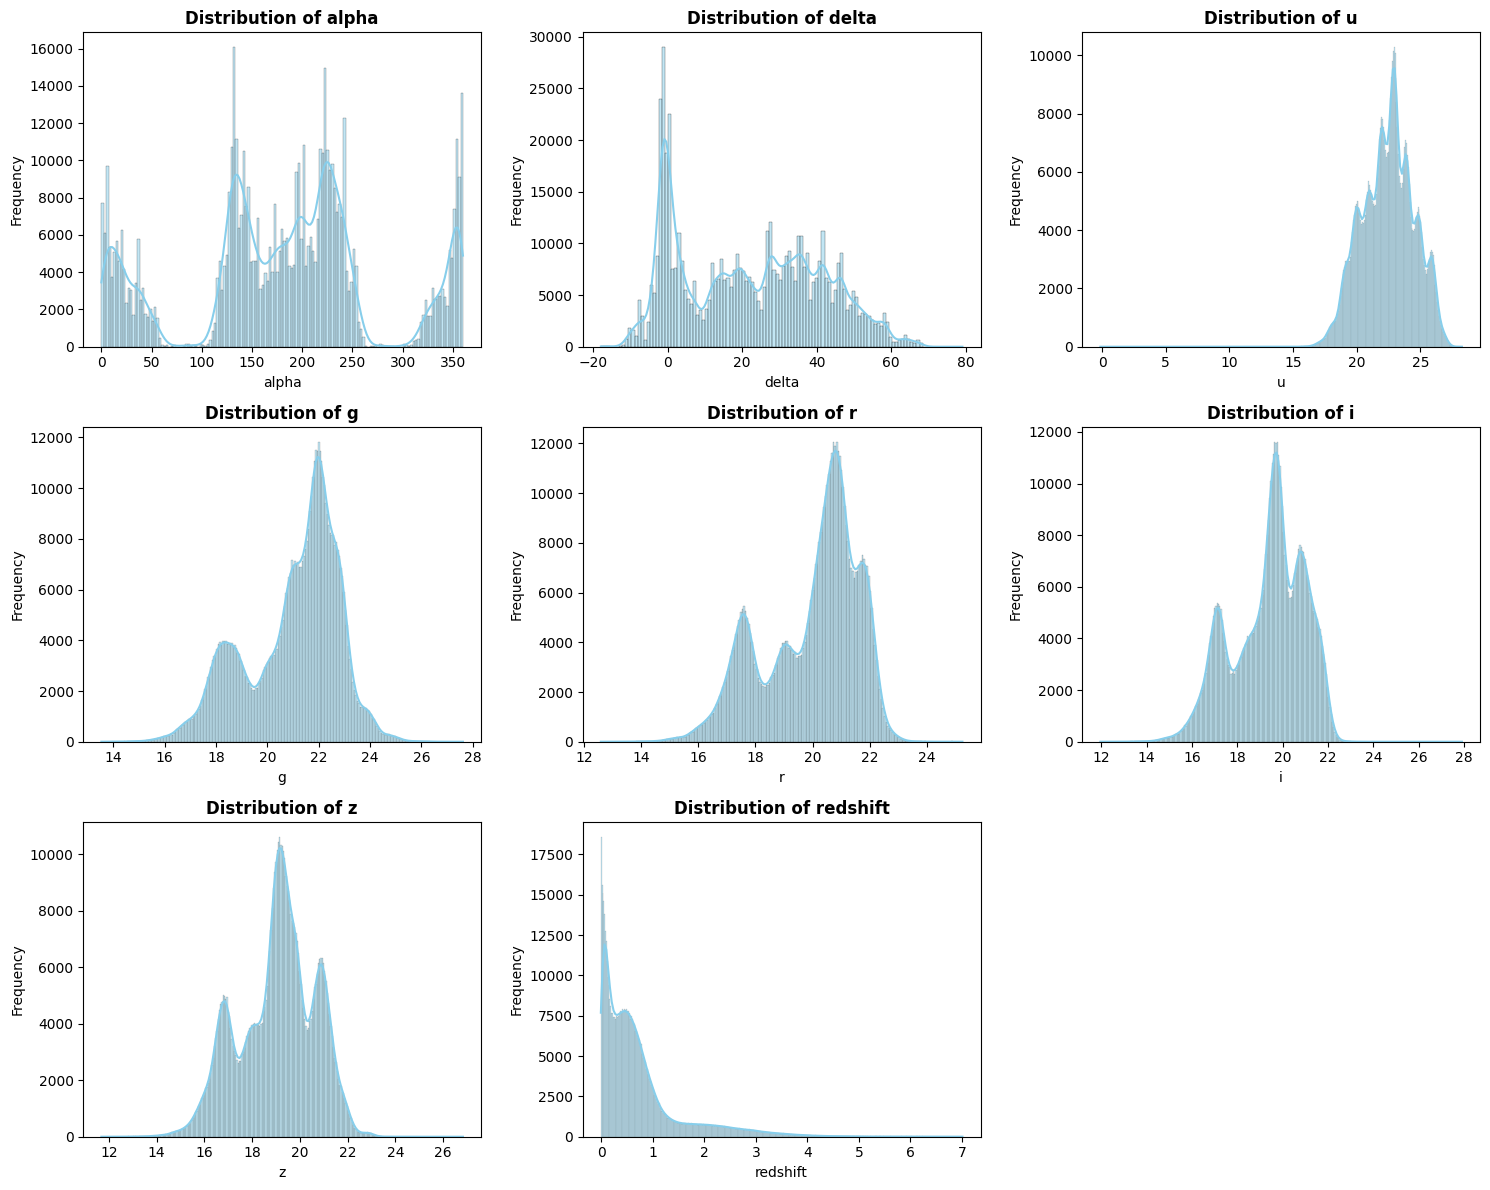

In [25]:
import numpy as np
import matplotlib.pyplot as plt # type:ignore
import seaborn as sns # type:ignore

# 2. Programmatically filter out only numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'id' in numerical_cols:
    numerical_cols.remove('id')  # Remove 'id' if it's present, as it's not a feature for analysis

# 3. Configure a dynamic grid layout
n_cols = 3  # Number of columns you want per row
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols  # Automatically compute required rows

# 4. Initialize the subplot grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

# Flatten the axes array to easily iterate through it sequentially
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes]

# 5. Populate the subplots
for i, col in enumerate(numerical_cols):
    # Plot histogram with a smooth density line (KDE)
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue', edgecolor='black')
    
    # Label formatting for clarity and presentation
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)

# 6. Turn off and hide empty subplots if grid spaces exceed total variables
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# 7. Prevent overlapping elements and adjust spacing
plt.tight_layout()
plt.show()

## Box Plot 

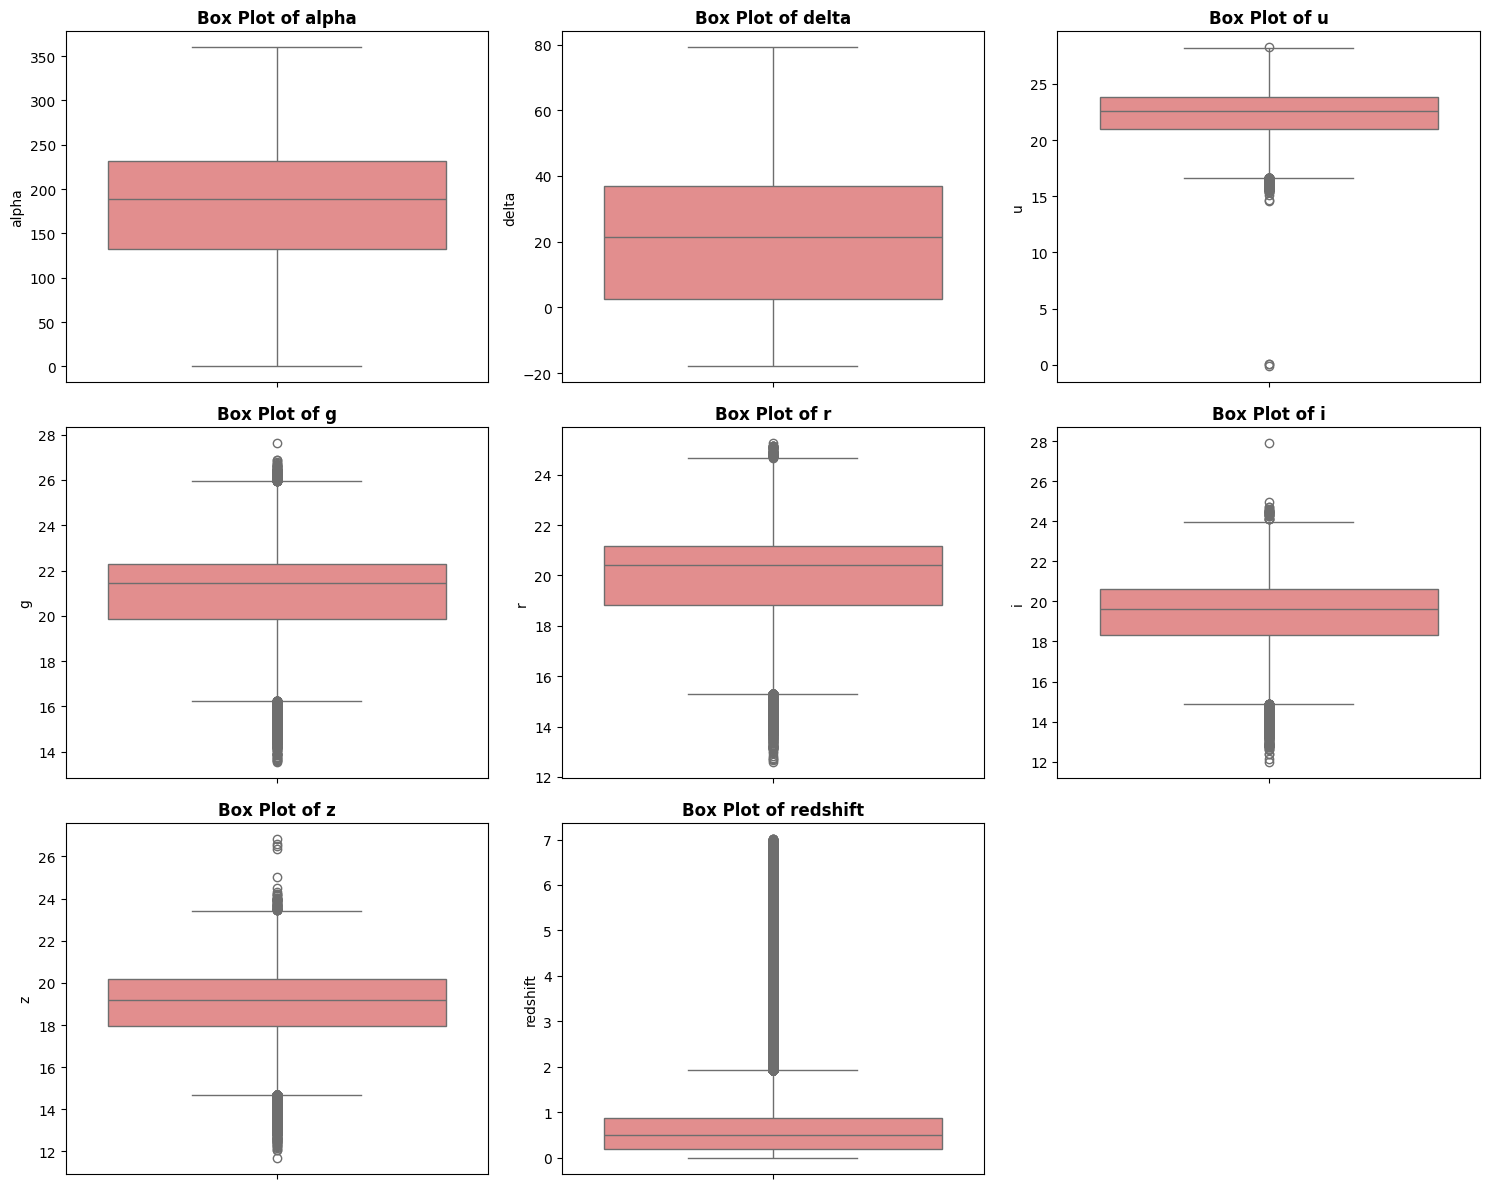

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # type:ignore
import seaborn as sns # type:ignore

# 2. Programmatically filter out only numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'id' in numerical_cols:
    numerical_cols.remove('id')  # Remove 'id' if it's present, as it's not a feature for analysis

# 3. Configure a dynamic grid layout
n_cols = 3  # Number of columns you want per row
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols  # Automatically compute required rows

# 4. Initialize the subplot grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

# Flatten the axes array to easily iterate through it sequentially
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes]

# 5. Populate the subplots
for i, col in enumerate(numerical_cols):
    # Plot box plot vertically
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    
    # Label formatting for clarity and presentation
    axes[i].set_title(f'Box Plot of {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col, fontsize=10)
    axes[i].set_xlabel('') # Clear out the x-axis label for single boxplots

# 6. Turn off and hide empty subplots if grid spaces exceed total variables
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# 7. Prevent overlapping elements and adjust spacing
plt.tight_layout()
plt.show()

## Encoding

In [27]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder # type:ignore

# 1. Correctly handle the Target Variable ('class')
# Convert strings ('GALAXY', 'QSO', 'STAR') into clean integers (0, 1, 2)
target_encoder = LabelEncoder()
df['class'] = target_encoder.fit_transform(df['class'])

# Extract the original string names from your encoder
my_target_names = target_encoder.classes_
print("My target names are:", my_target_names)
# Output: ['GALAXY' 'QSO' 'STAR']

# 2. Define the categorical FEATURE columns to be One-Hot Encoded
feature_cols = ['spectral_type', 'galaxy_population']

# 3. Apply One-Hot Encoding strictly matching your constraints
df_final = pd.get_dummies(
    df,
    columns=feature_cols,
    prefix='',          # Removes the column name prefix
    prefix_sep='',      # Removes the default underscore connector
    drop_first=True,    # Drops 1 column per feature to avoid multicollinearity
    dtype=int           # Generates clean 0 and 1 integers instead of Booleans
)

My target names are: ['GALAXY' 'QSO' 'STAR']


In [28]:
df_final.head()

,alpha,delta,u,g,r,i,z,redshift,class,G/K,M,O/B,Red_Sequence
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0,0,1,0,1
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0,0,1,0,1
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,1,0,0,1,0
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,0,0,1,0,1
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,0,0,1,0,1


In [29]:
X = df_final.drop(columns=['class'])
Y = df_final['class']

In [30]:
from sklearn.model_selection import train_test_split # type:ignore

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## SVM

In [31]:
# import pandas as pd
# from sklearn.model_selection import train_test_split # type:ignore
# from sklearn.preprocessing import StandardScaler # type:ignore
# from sklearn.svm import SVC # type:ignore
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # type:ignore
# from sklearn.datasets import load_iris # type:ignore


# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # 5. Initialize the SVM Model
# # kernel='rbf' is standard. You can also try 'linear', 'poly', or 'sigmoid'
# # C is the regularization parameter. 
# svm_model = SVC(kernel='rbf', C=1.0, random_state=42)

# # 6. Train the Model
# svm_model.fit(X_train_scaled, Y_train)

# # 7. Make Predictions on the test set
# y_pred = svm_model.predict(X_test_scaled)

# # 8. Evaluate the Model
# accuracy = accuracy_score(Y_test, y_pred)
# print(f"Accuracy: {accuracy * 100:.2f}%\n")

## Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier # type:ignore
from sklearn.preprocessing import StandardScaler # type:ignore
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # type:ignore

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Initialize the Random Forest Model
# n_estimators=100 means the model will build 100 individual decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 6. Train the Model
rf_model.fit(X_train_scaled, Y_train)

# 7. Make Predictions on the test set
y_pred = rf_model.predict(X_test_scaled)

# 8. Evaluate the Model (EXACTLY THE SAME METRICS)
accuracy = accuracy_score(Y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(Y_test, y_pred, target_names=my_target_names))

print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred, target_names=my_target_names))

Accuracy: 96.10%

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.97      0.97      0.97     75694
         QSO       0.96      0.96      0.96     23243
        STAR       0.91      0.90      0.90     16533

    accuracy                           0.96    115470
   macro avg       0.95      0.95      0.95    115470
weighted avg       0.96      0.96      0.96    115470

Confusion Matrix:
[[73720   733  1241]
 [  636 22340   267]
 [ 1543    86 14904]]


In [ ]:
import pandas as pd

# 1. Load your test dataset 
# (Replace 'test.csv' with your actual test file name)
df_test = pd.read_csv('D:\\Aniket\\Kaggle_Competition\\Stellar_Class\\Data\\test.csv')

# 2. Save the 'id' column for the final file, then drop it from the features
# We must drop it so the model doesn't try to use the ID as a mathematical feature
test_ids = df_test['id']
X_test_final = df_test.drop(columns=['id'])

# 2. Define the categorical FEATURE columns to be One-Hot Encoded
feature_cols = ['spectral_type', 'galaxy_population']

# 3. Apply One-Hot Encoding strictly matching your constraints
X_test_final = pd.get_dummies(
    X_test_final,
    columns=feature_cols,
    prefix='',          # Removes the column name prefix
    prefix_sep='',      # Removes the default underscore connector
    drop_first=True,    # Drops 1 column per feature to avoid multicollinearity
    dtype=int           # Generates clean 0 and 1 integers instead of Booleans
)

X_test_scaled = scaler.transform(X_test_final) 
# -----------------------------

# 3. Make predictions using your trained model (e.g., rf_model)
raw_predictions = rf_model.predict(X_test_scaled)

# 4. Convert numbers (0, 1, 2) back to their original string names ('GALAXY', 'QSO', 'STAR')
# Since you used target_encoder earlier, it can reverse the transformation perfectly!
final_predictions = target_encoder.inverse_transform(raw_predictions)

# 5. Create the submission DataFrame mapping the IDs to the predicted classes
submission_df = pd.DataFrame({
    'id': test_ids,
    'class': final_predictions  # Change this to raw_predictions if you want the 0,1,2 numbers instead
})

# 6. Save to CSV
# index=False is crucial! It prevents Pandas from adding an extra column of row numbers
submission_df.to_csv('D:\\Aniket\\Kaggle_Competition\\Stellar_Class\\Data\\submission.csv', index=False)

print("Predictions successfully saved to submission.csv!")

Predictions successfully saved to submission.csv!


In [36]:
df_submission = pd.read_csv('D:\\Aniket\\Kaggle_Competition\\Stellar_Class\\Data\\submission.csv')

In [ ]:
df_submission.head(5)

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


In [38]:
df_submission.shape

(247435, 2)